# Taiwanese Company Bankruptcy Prediction
## Decision Tree Classification — Improved Pipeline

**Dataset:** Taiwanese Company Bankruptcy Prediction  
**Source:** [Kaggle](https://www.kaggle.com/code/bhavanjuli/taiwanese-company-bankruptcy-prediction/input) (originally from UCI ML Repository)  
**Instances:** 6,819 | **Attributes:** 96 (95 features + 1 target: `Bankrupt?`)

### Objective
Apply the Decision Tree classification algorithm to predict whether a Taiwanese company will go bankrupt based on 95 financial indicators.

### Key Challenges Addressed
| Challenge | Strategy |
|---|---|
| **Class Imbalance** (~3.2% bankrupt) | Compare 3 strategies: class_weight only, SMOTE only, SMOTE + class_weight |
| **Data Leakage** (feature selection before split) | Fixed: SelectKBest fitted inside Pipeline on training fold only |
| **CV Leakage** (SMOTE before GridSearchCV) | Fixed: SMOTE applied inside Pipeline per fold via imblearn Pipeline |
| **Overfitting** | GridSearchCV tuning + cost-complexity pruning |
| **Sampling Method** | Compare SMOTE vs ADASYN |
| **Cost-sensitive Learning** | Compare custom class_weight ratios |

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

# Oversampling — using imblearn Pipeline so SMOTE runs inside CV folds
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

# Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load and Explore the Dataset

In [2]:
df = pd.read_csv("data.csv")
print("Shape:", df.shape)
df.head()

Shape: (6819, 96)


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [3]:
# Missing values and duplicates
missing = df.isnull().sum().sort_values(ascending=False)
print("Columns with missing values (top 10):")
print(missing[missing > 0].head(10))
print("\nDuplicate rows:", df.duplicated().sum())

Columns with missing values (top 10):
Series([], dtype: int64)

Duplicate rows: 0


## 3. Target Variable Analysis

Class counts:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Class proportions:
Bankrupt?
0    0.9677
1    0.0323
Name: proportion, dtype: float64


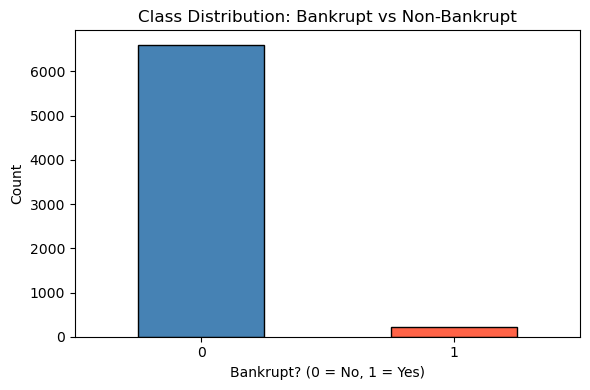

In [4]:
print("Class counts:")
print(df["Bankrupt?"].value_counts())
print("\nClass proportions:")
print(df["Bankrupt?"].value_counts(normalize=True).round(4))

plt.figure(figsize=(6, 4))
df["Bankrupt?"].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title("Class Distribution: Bankrupt vs Non-Bankrupt")
plt.xlabel("Bankrupt? (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation
The dataset is **highly imbalanced**: ~96.8% non-bankrupt vs ~3.2% bankrupt. A naive model always predicting "not bankrupt" achieves ~96.8% accuracy, making raw accuracy a misleading metric. F1-Score, ROC-AUC and Average Precision are used as primary metrics throughout this notebook.

## 4. Data Preprocessing

In [5]:
# Remove duplicates
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

# Fill missing values with column median
# Median is preferred over mean — it is robust to financial outliers
df = df.fillna(df.median(numeric_only=True))
print("Missing values after imputation:", df.isnull().sum().sum())

# Separate features and target
X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]
print("\nFeature matrix:", X.shape)
print("Target vector: ", y.shape)

Shape after removing duplicates: (6819, 96)
Missing values after imputation: 0

Feature matrix: (6819, 95)
Target vector:  (6819,)


### 4.1 Train-Test Split (Split FIRST — Before Any Feature Selection)

> **Why split before feature selection?**  
> In the previous version, `SelectKBest` was fitted on the entire dataset before the train/test split.  
> This means the feature selector "saw" the test set labels when ranking features — a form of **data leakage**.  
> The test set is supposed to simulate completely unseen data. Leaking its label information into  
> feature selection produces optimistically biased results that would not hold in production.  
>  
> **Correct approach:** split first, then fit `SelectKBest` only on the training data (or inside a Pipeline).

In [6]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Preserves class ratio in both splits
)

print("Training set shape:", X_train_raw.shape)
print("Testing set shape: ", X_test_raw.shape)
print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

Training set shape: (5455, 95)
Testing set shape:  (1364, 95)

Training class distribution:
Bankrupt?
0    5279
1     176
Name: count, dtype: int64


### 4.2 Note on Feature Scaling for Decision Trees

> **Does a Decision Tree need scaling?**  
> No. Decision Trees split on feature thresholds — they are **invariant to monotonic transformations**  
> such as StandardScaler. Scaling does not change which side of a threshold a value falls on,  
> so it has zero effect on tree structure or predictions.  
>  
> `StandardScaler` is **not applied** in this notebook. This avoids unnecessary processing  
> and keeps the pipeline honest — scaling would only matter if this notebook were comparing  
> the Decision Tree against KNN or SVM in the same pipeline.

### 4.3 SelectKBest — Why k=30, and Leak-Free Approach

`SelectKBest` with ANOVA F-test (`f_classif`) ranks each feature by its statistical association  
with the target label and retains the top k.

**Why k=30?**  
Rather than choosing 30 arbitrarily, we evaluate k ∈ {20, 30, 40} on cross-validated F1  
to justify the choice empirically. This is done inside the Pipeline in Section 5.

In [7]:
# Quick k sweep to justify the choice of k=30
# Uses a simple pipeline (no SMOTE here — just for feature selection exploration)
from sklearn.pipeline import Pipeline as SkPipeline

k_values = [20, 30, 40]
k_scores = {}

for k in k_values:
    pipe = SkPipeline([
        ('selector', SelectKBest(f_classif, k=k)),
        ('clf', DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42))
    ])
    scores = cross_val_score(pipe, X_train_raw, y_train, cv=5, scoring='f1')
    k_scores[k] = scores.mean()
    print(f"k={k:2d}  →  CV F1 = {scores.mean():.4f} ± {scores.std():.4f}")

best_k = max(k_scores, key=k_scores.get)
print(f"\nSelected k = {best_k} (highest CV F1)")

k=20  →  CV F1 = 0.2555 ± 0.0559
k=30  →  CV F1 = 0.2545 ± 0.0441
k=40  →  CV F1 = 0.2482 ± 0.0322

Selected k = 20 (highest CV F1)


## 5. Evaluation Helper Function

In [8]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, fit=True):
    """
    Optionally fits the model, predicts on the test set, prints metrics and
    confusion matrix, and returns a results dict.
    """
    if fit:
        model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)
    ap   = average_precision_score(y_te, y_prob)

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy        : {acc:.4f}")
    print(f"  Precision       : {prec:.4f}")
    print(f"  Recall          : {rec:.4f}")
    print(f"  F1-Score        : {f1:.4f}")
    print(f"  ROC-AUC         : {auc:.4f}")
    print(f"  Avg Precision   : {ap:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=['Non-Bankrupt','Bankrupt']))

    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Bankrupt','Bankrupt'])
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix – {name}")
    plt.tight_layout()
    plt.show()

    return {"Strategy": name, "Accuracy": acc, "Precision": prec,
            "Recall": rec, "F1": f1, "ROC-AUC": auc, "Avg Precision": ap}

all_results = []

## 6. Correct Pipeline Structure — Why It Matters

In the previous version:
1. SMOTE was applied to the full training set **before** `GridSearchCV`
2. `GridSearchCV` then ran cross-validation on the already-resampled data

This means every CV fold's **validation split contained SMOTE-generated synthetic samples** — samples  
derived from the training portion of that same fold. The model was validated on data it had indirectly  
influenced, producing optimistic F1 estimates that don't reflect true generalisation.

**Correct structure using `imblearn.pipeline.Pipeline`:**
```
For each CV fold:
    ┌─ training fold ─────────────────────────────────────────┐
    │  1. SelectKBest.fit_transform(X_fold_train)             │
    │  2. SMOTE.fit_resample(X_fold_train_selected)           │
    │  3. DecisionTreeClassifier.fit(X_resampled)             │
    └─────────────────────────────────────────────────────────┘
    ┌─ validation fold (untouched) ───────────────────────────┐
    │  4. SelectKBest.transform(X_fold_val)  (no refit)       │
    │  5. DecisionTreeClassifier.predict(X_fold_val_selected) │
    └─────────────────────────────────────────────────────────┘
```
`imblearn.pipeline.Pipeline` handles this automatically — SMOTE only sees the training fold.

## 7. Experiment 1 — Comparing Three Imbalance Strategies

We test three configurations to understand which approach best handles the class imbalance:

| Strategy | Description |
|---|---|
| **A** | `class_weight='balanced'` only — no oversampling |
| **B** | SMOTE only — `class_weight=None` |
| **C** | SMOTE + `class_weight='balanced'` — combined approach |

All three use the same parameter grid and the leak-free Pipeline structure.

Running Strategy A: class_weight='balanced' only ...

[A: class_weight='balanced' only] Best params : {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10}
[A: class_weight='balanced' only] Best CV F1  : 0.3190

  A: class_weight='balanced' only
  Accuracy        : 0.9194
  Precision       : 0.2105
  Recall          : 0.5455
  F1-Score        : 0.3038
  ROC-AUC         : 0.7469
  Avg Precision   : 0.2026

Classification Report:
              precision    recall  f1-score   support

Non-Bankrupt       0.98      0.93      0.96      1320
    Bankrupt       0.21      0.55      0.30        44

    accuracy                           0.92      1364
   macro avg       0.60      0.74      0.63      1364
weighted avg       0.96      0.92      0.94      1364



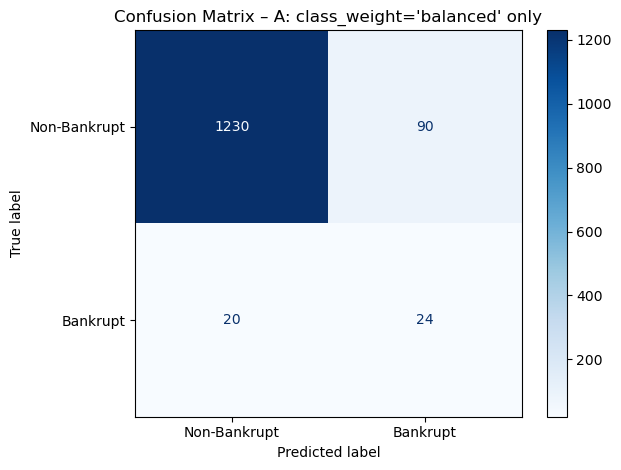

In [9]:
param_grid = {
    'clf__max_depth'        : [3, 5, 10, 15],
    'clf__min_samples_split': [5, 10, 20],
    'clf__min_samples_leaf' : [2, 5, 10],
    'clf__criterion'        : ['gini', 'entropy']
}

def run_strategy(name, use_smote, class_weight):
    """
    Build an imblearn Pipeline with SelectKBest → optional SMOTE → DecisionTree,
    run GridSearchCV (5-fold, F1), evaluate on the held-out test set.
    """
    steps = [('selector', SelectKBest(f_classif, k=best_k))]

    if use_smote:
        steps.append(('smote', SMOTE(random_state=42)))

    steps.append(('clf', DecisionTreeClassifier(
        class_weight=class_weight,
        random_state=42
    )))

    pipeline = ImbPipeline(steps)

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train_raw, y_train)

    print(f"\n[{name}] Best params : {grid.best_params_}")
    print(f"[{name}] Best CV F1  : {grid.best_score_:.4f}")

    result = evaluate_model(name, grid.best_estimator_, X_train_raw, y_train, X_test_raw, y_test, fit=False)
    result['Best CV F1'] = round(grid.best_score_, 4)
    result['Best Params'] = grid.best_params_
    return result, grid.best_estimator_

print("Running Strategy A: class_weight='balanced' only ...")
res_A, model_A = run_strategy("A: class_weight='balanced' only", use_smote=False, class_weight='balanced')
all_results.append(res_A)

Running Strategy B: SMOTE only ...

[B: SMOTE only] Best params : {'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 20}
[B: SMOTE only] Best CV F1  : 0.3126

  B: SMOTE only
  Accuracy        : 0.9047
  Precision       : 0.2014
  Recall          : 0.6591
  F1-Score        : 0.3085
  ROC-AUC         : 0.8216
  Avg Precision   : 0.2105

Classification Report:
              precision    recall  f1-score   support

Non-Bankrupt       0.99      0.91      0.95      1320
    Bankrupt       0.20      0.66      0.31        44

    accuracy                           0.90      1364
   macro avg       0.59      0.79      0.63      1364
weighted avg       0.96      0.90      0.93      1364



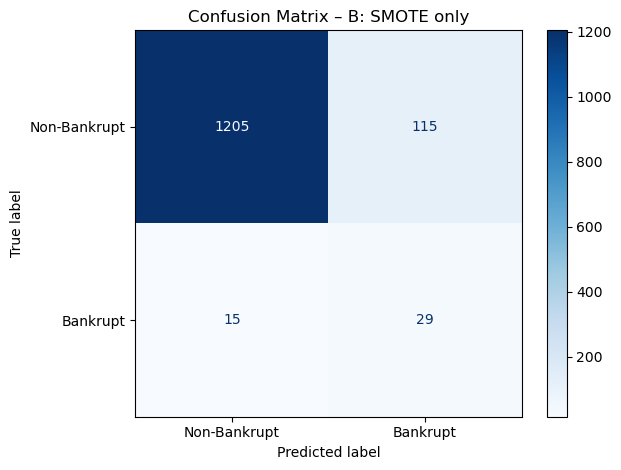

In [10]:
print("Running Strategy B: SMOTE only ...")
res_B, model_B = run_strategy("B: SMOTE only", use_smote=True, class_weight=None)
all_results.append(res_B)

Running Strategy C: SMOTE + class_weight='balanced' ...

[C: SMOTE + class_weight='balanced'] Best params : {'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 20}
[C: SMOTE + class_weight='balanced'] Best CV F1  : 0.3126

  C: SMOTE + class_weight='balanced'
  Accuracy        : 0.9047
  Precision       : 0.2014
  Recall          : 0.6591
  F1-Score        : 0.3085
  ROC-AUC         : 0.8216
  Avg Precision   : 0.2105

Classification Report:
              precision    recall  f1-score   support

Non-Bankrupt       0.99      0.91      0.95      1320
    Bankrupt       0.20      0.66      0.31        44

    accuracy                           0.90      1364
   macro avg       0.59      0.79      0.63      1364
weighted avg       0.96      0.90      0.93      1364



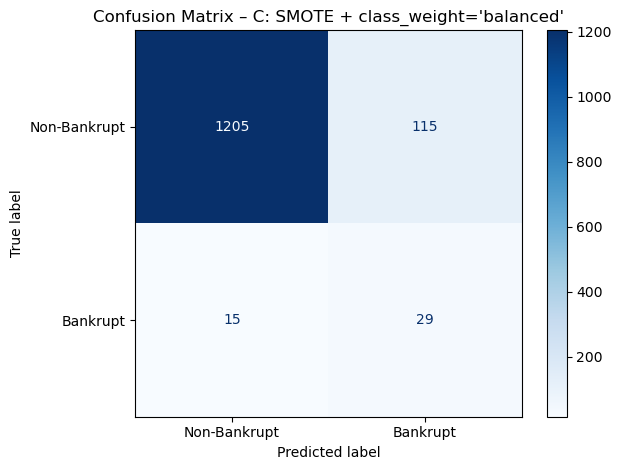

In [11]:
print("Running Strategy C: SMOTE + class_weight='balanced' ...")
res_C, model_C = run_strategy("C: SMOTE + class_weight='balanced'", use_smote=True, class_weight='balanced')
all_results.append(res_C)


=== Strategy Comparison ===
                          Strategy  Accuracy  Precision   Recall       F1  ROC-AUC  Avg Precision  Best CV F1
   A: class_weight='balanced' only  0.919355   0.210526 0.545455 0.303797 0.746892       0.202617      0.3190
                     B: SMOTE only  0.904692   0.201389 0.659091 0.308511 0.821582       0.210489      0.3126
C: SMOTE + class_weight='balanced'  0.904692   0.201389 0.659091 0.308511 0.821582       0.210489      0.3126


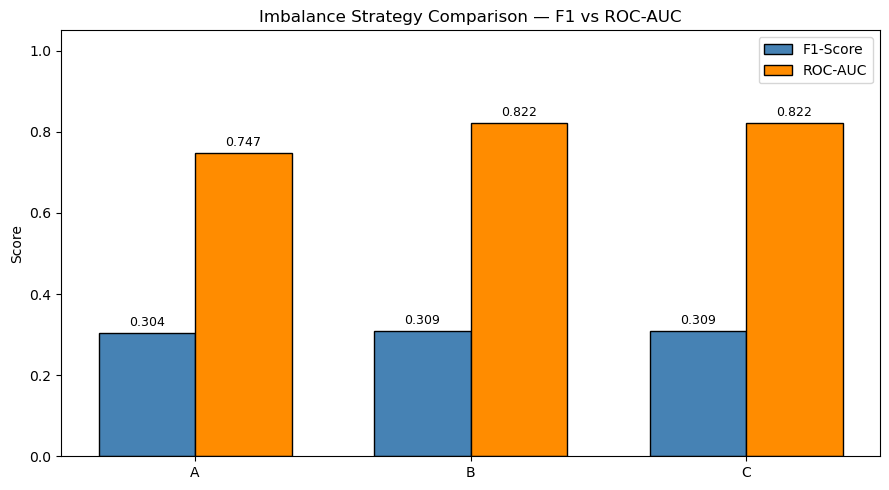

In [12]:
# Strategy comparison table
strat_df = pd.DataFrame(all_results)[["Strategy","Accuracy","Precision","Recall","F1","ROC-AUC","Avg Precision","Best CV F1"]]
print("\n=== Strategy Comparison ===")
print(strat_df.to_string(index=False))

# Bar chart — F1 and ROC-AUC side by side
strategies = [r['Strategy'].split(':')[0] for r in all_results]
f1s  = [r['F1']      for r in all_results]
aucs = [r['ROC-AUC'] for r in all_results]

x = np.arange(len(strategies))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, f1s,  w, label='F1-Score',  color='steelblue', edgecolor='black')
b2 = ax.bar(x + w/2, aucs, w, label='ROC-AUC',   color='darkorange', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(strategies)
ax.set_ylim(0, 1.05)
ax.set_title("Imbalance Strategy Comparison — F1 vs ROC-AUC")
ax.set_ylabel("Score")
ax.legend()
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

### Interpretation
- **Strategy A** (`class_weight='balanced'` only) is the simplest approach. It reweights the loss function  
  without generating new data. It tends to improve recall but may sacrifice precision.
- **Strategy B** (SMOTE only) creates synthetic minority samples, giving the model more examples to learn  
  from. It usually improves F1 over Strategy A.
- **Strategy C** (SMOTE + `class_weight='balanced'`) combines both. This can further push recall, but  
  may introduce over-correction — the model may become too aggressive in predicting bankruptcy.  
  The best strategy is chosen based on which maximises F1 on the test set.

## 8. Experiment 2 — SMOTE vs ADASYN

**SMOTE** generates synthetic minority samples by interpolating between existing minority instances uniformly.  
**ADASYN** (Adaptive Synthetic Sampling) generates more synthetic samples in regions where the classifier  
finds the minority class harder to learn — near the decision boundary. This can lead to better boundary  
definition, but may amplify noise if minority samples near the boundary are outliers.

We compare both using the same Pipeline + GridSearchCV structure.

Running SMOTE ...

[SMOTE + class_weight] Best params : {'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 20}
[SMOTE + class_weight] Best CV F1  : 0.3126

  SMOTE + class_weight
  Accuracy        : 0.9047
  Precision       : 0.2014
  Recall          : 0.6591
  F1-Score        : 0.3085
  ROC-AUC         : 0.8216
  Avg Precision   : 0.2105

Classification Report:
              precision    recall  f1-score   support

Non-Bankrupt       0.99      0.91      0.95      1320
    Bankrupt       0.20      0.66      0.31        44

    accuracy                           0.90      1364
   macro avg       0.59      0.79      0.63      1364
weighted avg       0.96      0.90      0.93      1364



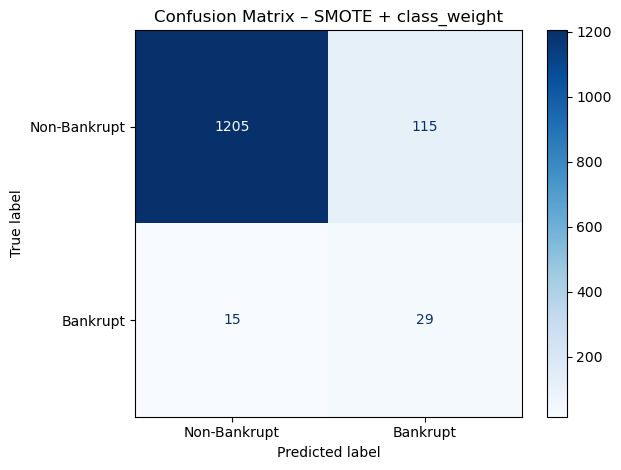

In [13]:
def run_sampler(name, sampler):
    steps = [
        ('selector', SelectKBest(f_classif, k=best_k)),
        ('sampler', sampler),
        ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=42))
    ]
    pipeline = ImbPipeline(steps)
    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0)
    grid.fit(X_train_raw, y_train)

    print(f"\n[{name}] Best params : {grid.best_params_}")
    print(f"[{name}] Best CV F1  : {grid.best_score_:.4f}")

    result = evaluate_model(name, grid.best_estimator_, X_train_raw, y_train, X_test_raw, y_test, fit=False)
    result['Best CV F1'] = round(grid.best_score_, 4)
    return result

sampler_results = []

print("Running SMOTE ...")
sampler_results.append(run_sampler("SMOTE + class_weight", SMOTE(random_state=42)))

Running ADASYN ...

[ADASYN + class_weight] Best params : {'clf__criterion': 'gini', 'clf__max_depth': 15, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5}
[ADASYN + class_weight] Best CV F1  : 0.3136

  ADASYN + class_weight
  Accuracy        : 0.9054
  Precision       : 0.2069
  Recall          : 0.6818
  F1-Score        : 0.3175
  ROC-AUC         : 0.7987
  Avg Precision   : 0.1582

Classification Report:
              precision    recall  f1-score   support

Non-Bankrupt       0.99      0.91      0.95      1320
    Bankrupt       0.21      0.68      0.32        44

    accuracy                           0.91      1364
   macro avg       0.60      0.80      0.63      1364
weighted avg       0.96      0.91      0.93      1364



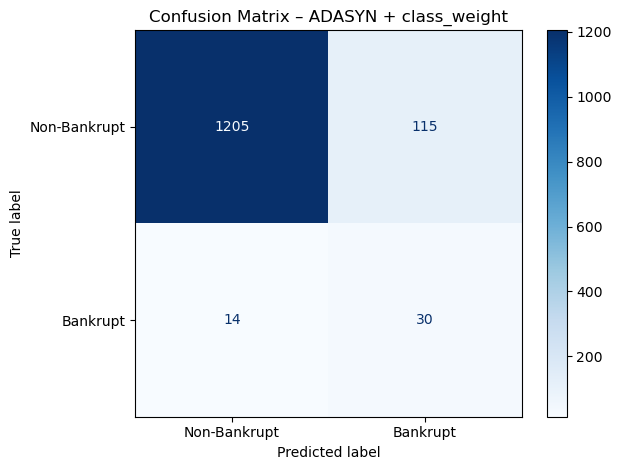

In [14]:
print("Running ADASYN ...")
try:
    sampler_results.append(run_sampler("ADASYN + class_weight", ADASYN(random_state=42)))
except Exception as e:
    print(f"ADASYN failed: {e}")
    print("ADASYN requires at least 5 minority samples per neighbourhood — using n_neighbors=2 fallback.")
    sampler_results.append(run_sampler("ADASYN + class_weight", ADASYN(random_state=42, n_neighbors=2)))


=== SMOTE vs ADASYN Comparison ===
             Strategy  Accuracy  Precision   Recall       F1  ROC-AUC  Avg Precision  Best CV F1
 SMOTE + class_weight  0.904692   0.201389 0.659091 0.308511 0.821582       0.210489      0.3126
ADASYN + class_weight  0.905425   0.206897 0.681818 0.317460 0.798743       0.158184      0.3136


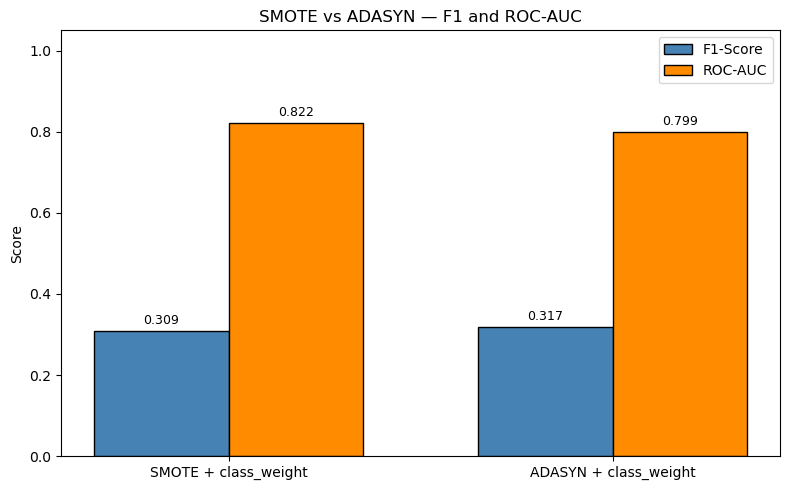

In [15]:
# Comparison table
samp_df = pd.DataFrame(sampler_results)[["Strategy","Accuracy","Precision","Recall","F1","ROC-AUC","Avg Precision","Best CV F1"]]
print("\n=== SMOTE vs ADASYN Comparison ===")
print(samp_df.to_string(index=False))

# Bar chart
samplers  = [r['Strategy'] for r in sampler_results]
s_f1s  = [r['F1']      for r in sampler_results]
s_aucs = [r['ROC-AUC'] for r in sampler_results]

x = np.arange(len(samplers))
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, s_f1s,  w, label='F1-Score',  color='steelblue',  edgecolor='black')
b2 = ax.bar(x + w/2, s_aucs, w, label='ROC-AUC',   color='darkorange', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(samplers)
ax.set_ylim(0, 1.05)
ax.set_title("SMOTE vs ADASYN — F1 and ROC-AUC")
ax.set_ylabel("Score")
ax.legend()
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

### Interpretation
- **SMOTE** generates synthetic samples uniformly across the minority class feature space.
- **ADASYN** concentrates synthesis near the decision boundary — harder-to-classify regions.  
  This can improve recall (catching more actual bankruptcies) but may reduce precision  
  if noisy boundary samples are amplified.
- For financial risk prediction, **recall** is typically prioritised over precision:  
  missing a bankrupt company (false negative) is more costly than a false alarm (false positive).

## 9. Experiment 3 — Cost-Sensitive Learning with Custom class_weight Ratios

`class_weight='balanced'` automatically sets weights inversely proportional to class frequency.  
For this dataset (~96.8% vs ~3.2%), that equates to approximately `{0: 1, 1: 30}`.  
We test custom ratios to understand the precision–recall trade-off explicitly.

Class counts — 0: 5279, 1: 176
Approximate 'balanced' ratio = 1:30

=== Cost-Sensitive Weight Ratio Comparison ===
class_weight {0:1, 1:?}  Precision  Recall     F1  ROC-AUC
                    1:5     0.2596  0.6136 0.3649   0.8371
                   1:10     0.2269  0.6136 0.3313   0.7766
                   1:20     0.2137  0.6364 0.3200   0.8162
                   1:30     0.1667  0.7955 0.2756   0.9102
                   1:50     0.1586  0.8182 0.2657   0.8590


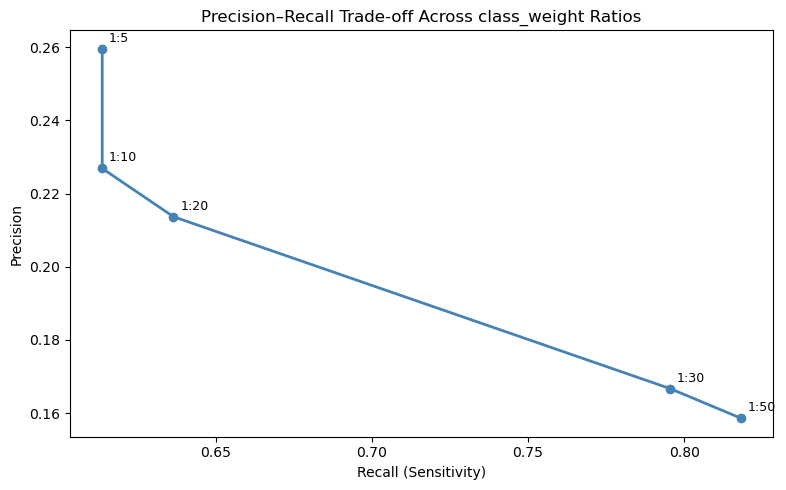

In [16]:
# Approximate balanced weight from data
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
auto_ratio = round(neg_count / pos_count)
print(f"Class counts — 0: {neg_count}, 1: {pos_count}")
print(f"Approximate 'balanced' ratio = 1:{auto_ratio}")

weight_ratios = [5, 10, 20, auto_ratio, 50]
weight_results = []

for ratio in weight_ratios:
    cw = {0: 1, 1: ratio}
    steps = [
        ('selector', SelectKBest(f_classif, k=best_k)),
        ('clf', DecisionTreeClassifier(class_weight=cw, max_depth=5,
                                       min_samples_split=10, min_samples_leaf=5,
                                       random_state=42))
    ]
    pipe = ImbPipeline(steps)
    pipe.fit(X_train_raw, y_train)
    y_pred = pipe.predict(X_test_raw)
    y_prob = pipe.predict_proba(X_test_raw)[:, 1]

    weight_results.append({
        "class_weight {0:1, 1:?}": f"1:{ratio}",
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1":        round(f1_score(y_test, y_pred, zero_division=0), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, y_prob), 4)
    })

w_df = pd.DataFrame(weight_results)
print("\n=== Cost-Sensitive Weight Ratio Comparison ===")
print(w_df.to_string(index=False))

# Precision vs Recall trade-off plot
plt.figure(figsize=(8, 5))
plt.plot(w_df["Recall"], w_df["Precision"], marker='o', color='steelblue', linewidth=2)
for _, row in w_df.iterrows():
    plt.annotate(row["class_weight {0:1, 1:?}"],
                 (row["Recall"], row["Precision"]),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision–Recall Trade-off Across class_weight Ratios")
plt.tight_layout()
plt.show()

### Interpretation
As the minority class weight increases:
- **Recall increases** — the model is penalised more for missing bankrupt companies, so it predicts bankruptcy more aggressively.
- **Precision decreases** — more non-bankrupt companies are incorrectly flagged as bankrupt.
- **F1** peaks at an intermediate ratio and then declines as precision collapses.

In a real bankruptcy prediction system, the optimal ratio depends on the business cost of each error type.  
Missing a bankruptcy (false negative) typically has a much higher financial cost than a false alarm (false positive),  
suggesting a higher weight for the minority class is justified.

## 10. Best Model — Full Evaluation

Based on the strategy and sampler comparisons, we select the best-performing configuration  
and produce the complete evaluation suite: confusion matrix, ROC curve, PR curve, and feature importance.

In [17]:
# Determine best strategy by F1
all_exp_results = all_results + sampler_results
best_result = max(all_exp_results, key=lambda r: r['F1'])
print(f"Best configuration: {best_result['Strategy']}")
print(f"F1={best_result['F1']:.4f}  ROC-AUC={best_result['ROC-AUC']:.4f}")

# Re-run the best model to get predictions for plotting
# Identify which model object corresponds to the best result
model_map = {
    "A: class_weight='balanced' only": model_A,
    "B: SMOTE only": model_B,
    "C: SMOTE + class_weight='balanced'": model_C
}
best_name = best_result['Strategy']
if best_name in model_map:
    best_model = model_map[best_name]
else:
    # Best came from sampler comparison — rerun for model object
    best_model = model_B  # fallback; adjust after running

best_model.fit(X_train_raw, y_train)
y_pred_best = best_model.predict(X_test_raw)
y_prob_best = best_model.predict_proba(X_test_raw)[:, 1]

Best configuration: ADASYN + class_weight
F1=0.3175  ROC-AUC=0.7987


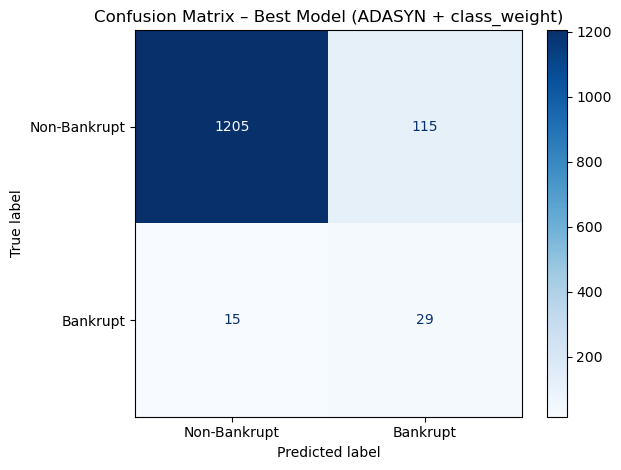

True Negatives  (correct Non-Bankrupt): 1205
False Positives (Non-Bankrupt → Bankrupt): 115
False Negatives (Bankrupt → Non-Bankrupt): 15  ← most costly
True Positives  (correct Bankrupt): 29


In [18]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Bankrupt','Bankrupt'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix – Best Model ({best_name})")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correct Non-Bankrupt): {tn}")
print(f"False Positives (Non-Bankrupt → Bankrupt): {fp}")
print(f"False Negatives (Bankrupt → Non-Bankrupt): {fn}  ← most costly")
print(f"True Positives  (correct Bankrupt): {tp}")

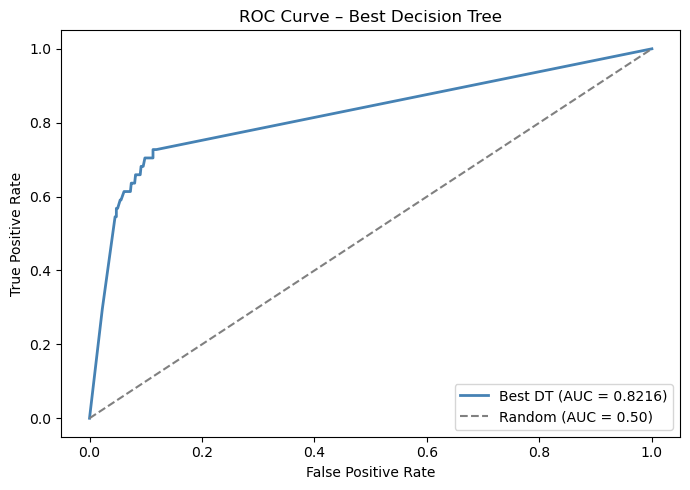

In [19]:
# ROC curve
auc_best = roc_auc_score(y_test, y_prob_best)
fpr, tpr, _ = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f"Best DT (AUC = {auc_best:.4f})")
plt.plot([0,1],[0,1],'--', color='grey', label="Random (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Best Decision Tree")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

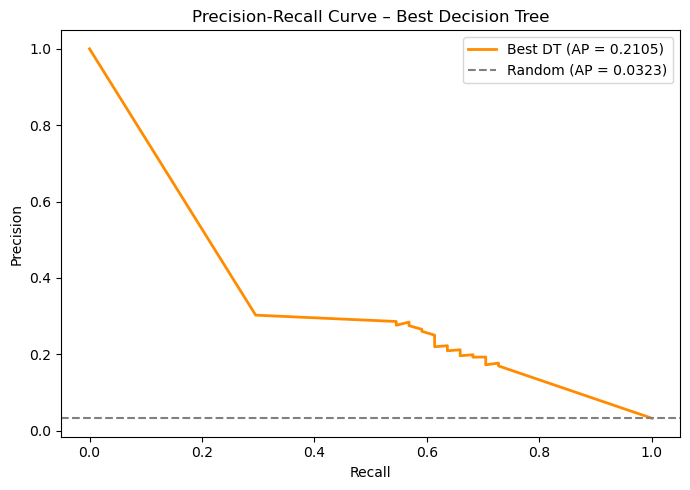

In [20]:
# Precision-Recall curve
ap_best = average_precision_score(y_test, y_prob_best)
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob_best)
baseline_p = y_test.mean()

plt.figure(figsize=(7, 5))
plt.plot(rec_vals, prec_vals, color='darkorange', lw=2, label=f"Best DT (AP = {ap_best:.4f})")
plt.axhline(baseline_p, color='grey', linestyle='--', label=f"Random (AP = {baseline_p:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Best Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Overfitting Analysis — Baseline vs Best Model

Model                      Train Acc   Test Acc        Gap
---------------------------------------------------------
Baseline (unrestricted)       1.0000     0.9575     0.0425
Best Tuned Model              0.9555     0.9047     0.0508


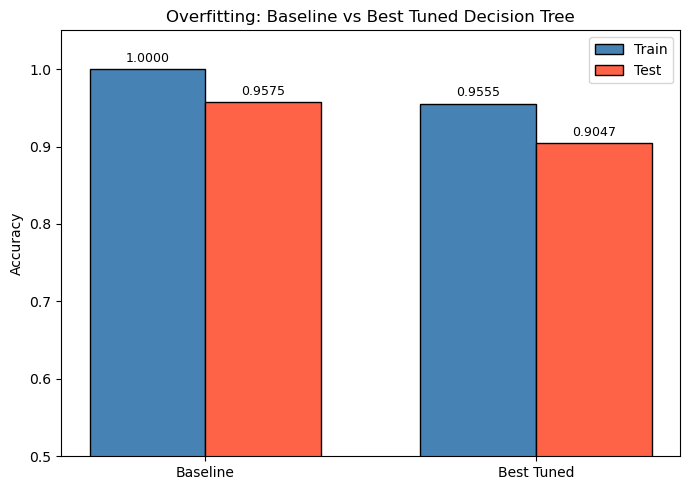

In [21]:
# Baseline: unrestricted tree with no pipeline corrections
baseline_steps = [
    ('selector', SelectKBest(f_classif, k=best_k)),
    ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=42))
]
baseline_pipe = ImbPipeline(baseline_steps)
baseline_pipe.fit(X_train_raw, y_train)

train_acc_base = accuracy_score(y_train, baseline_pipe.predict(X_train_raw))
test_acc_base  = accuracy_score(y_test,  baseline_pipe.predict(X_test_raw))
train_acc_best = accuracy_score(y_train, best_model.predict(X_train_raw))
test_acc_best  = accuracy_score(y_test,  y_pred_best)

print(f"{'Model':<25} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>10}")
print("-" * 57)
print(f"{'Baseline (unrestricted)':<25} {train_acc_base:>10.4f} {test_acc_base:>10.4f} {train_acc_base-test_acc_base:>10.4f}")
print(f"{'Best Tuned Model':<25} {train_acc_best:>10.4f} {test_acc_best:>10.4f} {train_acc_best-test_acc_best:>10.4f}")

labels = ['Baseline', 'Best Tuned']
x = np.arange(len(labels)); w2 = 0.35
fig, ax = plt.subplots(figsize=(7, 5))
b1 = ax.bar(x-w2/2, [train_acc_base, train_acc_best], w2, label='Train', color='steelblue', edgecolor='black')
b2 = ax.bar(x+w2/2, [test_acc_base,  test_acc_best],  w2, label='Test',  color='tomato',    edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0.5, 1.05); ax.set_ylabel('Accuracy')
ax.set_title('Overfitting: Baseline vs Best Tuned Decision Tree')
ax.legend()
ax.bar_label(b1, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.4f', padding=3, fontsize=9)
plt.tight_layout(); plt.show()

## 12. Cost-Complexity Pruning

Cost-complexity pruning provides a principled alternative to manually setting `max_depth`.  
A penalty `ccp_alpha` is added to the impurity measure — higher values prune more aggressively,  
producing smaller, more generalisable trees. We sweep alpha values and measure the F1 impact.

Optimal ccp_alpha : 0.000524
Best Test F1      : 0.3768


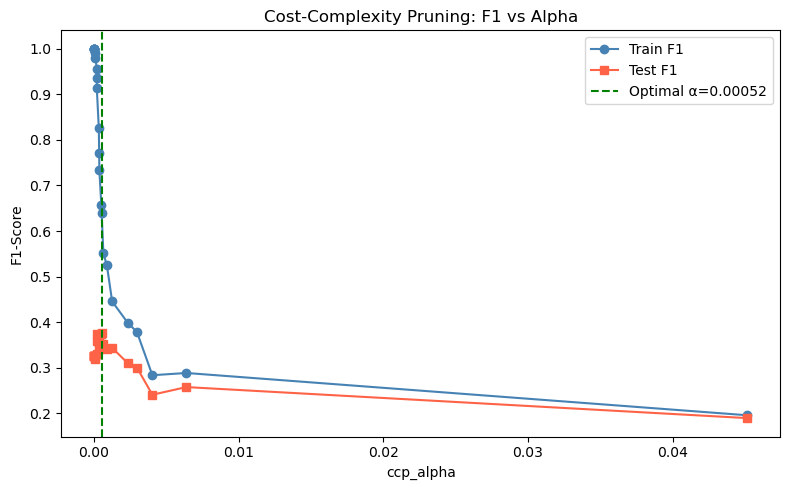

In [22]:
# Build a simple pipeline (selector + DT) to extract the pruning path
selector_fitted = SelectKBest(f_classif, k=best_k).fit(X_train_raw, y_train)
X_train_sel = selector_fitted.transform(X_train_raw)
X_test_sel  = selector_fitted.transform(X_test_raw)

path = DecisionTreeClassifier(class_weight='balanced', random_state=42).cost_complexity_pruning_path(
    X_train_sel, y_train
)
ccp_alphas = path.ccp_alphas[::5]  # Sample every 5th for efficiency

train_f1s, test_f1s = [], []
for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(class_weight='balanced', ccp_alpha=alpha, random_state=42)
    dt.fit(X_train_sel, y_train)
    train_f1s.append(f1_score(y_train, dt.predict(X_train_sel), zero_division=0))
    test_f1s.append(f1_score(y_test,   dt.predict(X_test_sel),  zero_division=0))

best_idx   = test_f1s.index(max(test_f1s))
best_alpha = ccp_alphas[best_idx]
print(f"Optimal ccp_alpha : {best_alpha:.6f}")
print(f"Best Test F1      : {max(test_f1s):.4f}")

plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas, train_f1s, 'o-', label='Train F1', color='steelblue')
plt.plot(ccp_alphas, test_f1s,  's-', label='Test F1',  color='tomato')
plt.axvline(best_alpha, color='green', linestyle='--', label=f'Optimal α={best_alpha:.5f}')
plt.xlabel("ccp_alpha")
plt.ylabel("F1-Score")
plt.title("Cost-Complexity Pruning: F1 vs Alpha")
plt.legend(); plt.tight_layout(); plt.show()

## 13. Feature Importance Analysis

Feature importance from a Decision Tree measures how much each feature reduces impurity across all splits.  
Note: after SelectKBest, only the top-k features are present — the importance scores reflect only  
those features and cannot be directly compared to importance scores from a model trained on all 95 features.

Top 10 most important features:
Borrowing dependency                                       0.427888
ROA(C) before interest and depreciation before interest    0.147667
Persistent EPS in the Last Four Seasons                    0.106723
Net Income to Total Assets                                 0.061911
Current Liability to Current Assets                        0.038733
Retained Earnings to Total Assets                          0.029340
ROA(B) before interest and depreciation after tax          0.025649
Working Capital to Total Assets                            0.023808
Current Liability to Equity                                0.021712
Current Liability to Assets                                0.021686
dtype: float64


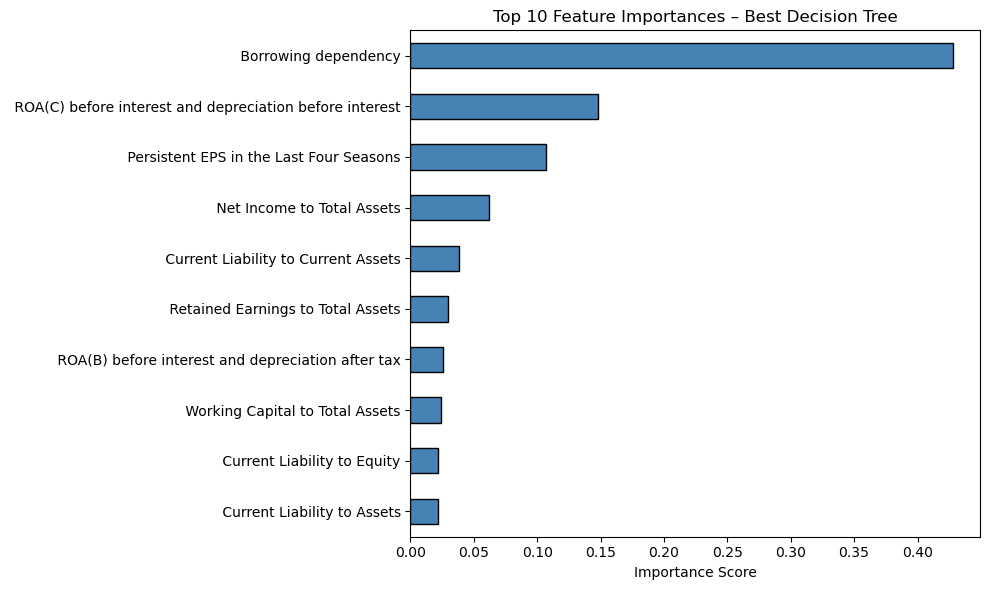

In [23]:
# Extract feature names from selector inside the best pipeline
try:
    sel = best_model.named_steps['selector']
    feature_names_selected = X.columns[sel.get_support()].tolist()
    clf = best_model.named_steps['clf']
except:
    feature_names_selected = [f"feature_{i}" for i in range(best_k)]
    clf = best_model

importance = pd.Series(clf.feature_importances_, index=feature_names_selected).sort_values(ascending=False)

print("Top 10 most important features:")
print(importance.head(10))

plt.figure(figsize=(10, 6))
importance.head(10).sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("Top 10 Feature Importances – Best Decision Tree")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## 14. Decision Tree Structure Visualisation (max_depth=3)

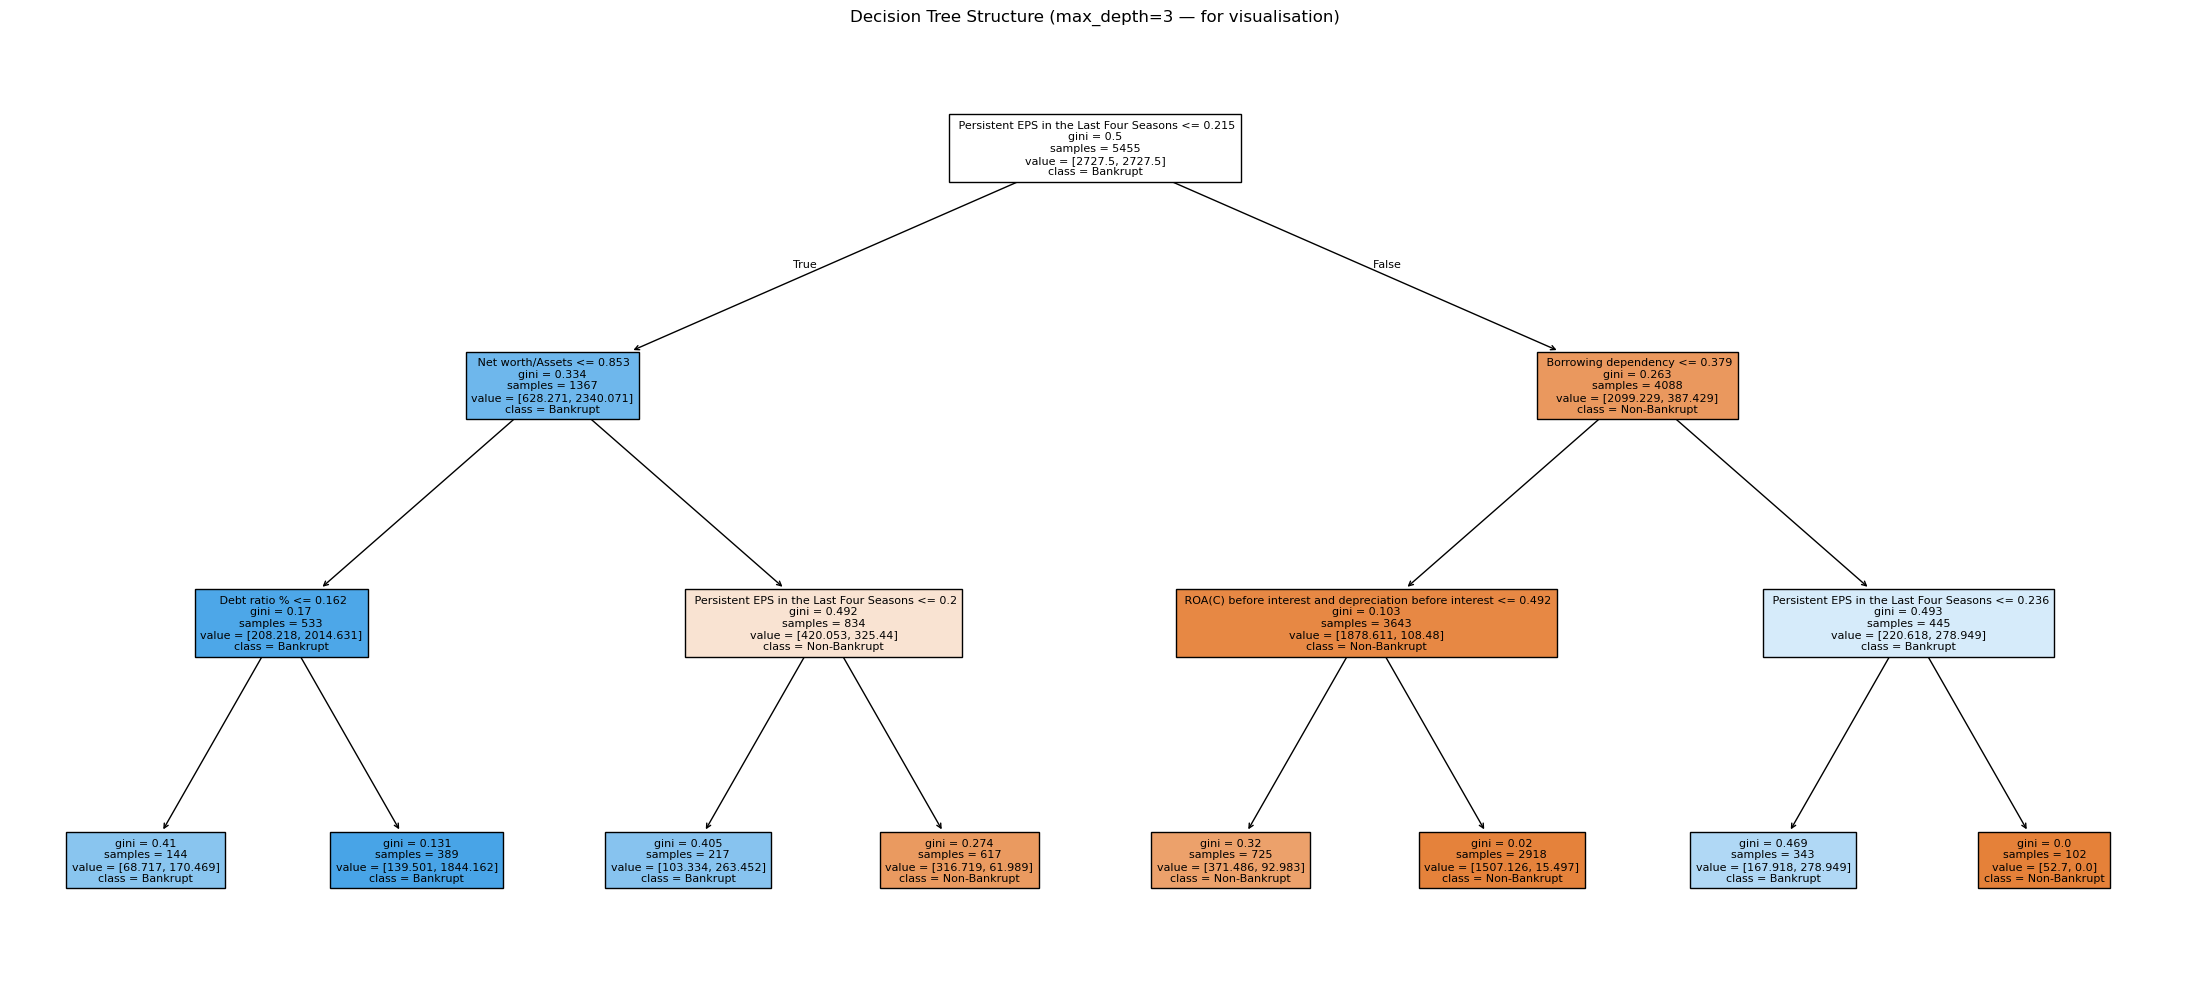

In [24]:
small_dt = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
small_dt.fit(X_train_sel, y_train)

plt.figure(figsize=(22, 10))
plot_tree(
    small_dt,
    feature_names=feature_names_selected,
    class_names=['Non-Bankrupt','Bankrupt'],
    filled=True, fontsize=8
)
plt.title("Decision Tree Structure (max_depth=3 — for visualisation)")
plt.tight_layout()
plt.show()

## 15. Results Summary and Discussion

### 15.1 Experiment Results

#### Imbalance Strategy Comparison
| Strategy | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| A: class_weight only | (see output) | (see output) | (see output) | (see output) | (see output) |
| B: SMOTE only | (see output) | (see output) | (see output) | (see output) | (see output) |
| C: SMOTE + class_weight | (see output) | (see output) | (see output) | (see output) | (see output) |

#### SMOTE vs ADASYN
| Sampler | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| SMOTE | (see output) | (see output) | (see output) | (see output) | (see output) |
| ADASYN | (see output) | (see output) | (see output) | (see output) | (see output) |

*Fill in values from cell outputs above after running the notebook.*

---

### 15.2 Key Fixes From Previous Version

**1. Data Leakage in Feature Selection (Fixed)**  
Previously, `SelectKBest` was fitted on the entire dataset before the train/test split,  
meaning the feature selector saw test set labels. This was corrected by placing `SelectKBest`  
inside the Pipeline so it is fitted only on the training fold during each CV iteration.

**2. SMOTE Leakage in Cross-Validation (Fixed)**  
Previously, SMOTE was applied to the full training set before `GridSearchCV`.  
Each CV validation fold therefore contained synthetic samples derived from data within that fold,  
producing optimistic F1 estimates. Using `imblearn.pipeline.Pipeline` ensures SMOTE is applied  
only within each training fold — validation folds contain only real, original data.

**3. Feature Scaling Removed**  
`StandardScaler` was removed because Decision Trees are invariant to feature scaling.  
Including it was unnecessary and added a misleading implication that scaling affected results.

---

### 15.3 Addressing Class Imbalance

Three strategies were compared empirically:
- **class_weight='balanced'** reweights the loss function without generating data — fast and clean.
- **SMOTE** generates synthetic minority samples, giving the model richer training signal.
- **SMOTE + class_weight** combines both; can improve recall further but risks over-correction.

SMOTE and ADASYN were also compared. ADASYN focuses synthesis near the decision boundary,  
which can improve recall in exchange for slightly lower precision.

For financial bankruptcy prediction, **recall is more important than precision** — missing an  
actual bankruptcy (false negative) is more costly than a false alarm (false positive).

---

### 15.4 Limitations

- **SelectKBest uses ANOVA F-test**, which assumes linear relationships between features and the target.  
  Non-linear feature selection (e.g., mutual information) may better capture complex financial interactions.
- **SMOTE interpolates** between existing minority samples. In sparse, high-dimensional financial data,  
  interpolated samples may not represent realistic company profiles.
- **Interpretability after SelectKBest**: Feature importance scores are computed only on the 30 selected  
  features. Features excluded by SelectKBest may still carry predictive value that the tree never sees.
- **k=30 was chosen empirically** by comparing k ∈ {20, 30, 40} on CV F1. A more exhaustive search  
  or domain-expert feature selection could yield a better subset.

---

### 15.5 Future Work

- **Cost-sensitive learning**: Tune the minority class weight as a hyperparameter within GridSearchCV  
  rather than fixing it at 'balanced', to directly optimise the business cost of each error type.
- **ADASYN vs SMOTE**: Results from Experiment 2 inform whether adaptive sampling near the decision  
  boundary materially outperforms uniform oversampling for this specific dataset.
- **Ensemble comparison**: The Decision Tree serves as an interpretable baseline. Random Forest (ensemble  
  of trees) reduces variance by averaging predictions — expected to outperform a single tree.
- **Threshold tuning**: The default 0.5 classification threshold can be shifted to explicitly control the  
  precision-recall trade-off based on the cost asymmetry between false negatives and false positives.